# Verification: Arc-Cosine Random Features ≈ Arc-Cosine Kernel

**Purpose.** The arc-cosine kernel of degree $n$ (Cho & Saul, 2010) is defined by the integral representation:

$$k_n(x, y) = 2\int \frac{e^{-\|w\|^2/2}}{(2\pi)^{d/2}} \,\Theta(w^\top x)\,\Theta(w^\top y)\, (w^\top x)^n (w^\top y)^n \, dw = \mathbb{E}_{w \sim \mathcal{N}(0,I)}[\phi_w(x)\phi_w(y)]$$

where $\phi_w(x) = \sqrt{2}\,\max(0, w^\top x)^n$.

We propose approximating this kernel by drawing $P$ i.i.d. samples $w_j \sim \mathcal{N}(0, I)$ and forming:

$$\hat{k}_n(x,y) = \frac{1}{P} \sum_{j=1}^P \phi_{w_j}(x)\,\phi_{w_j}(y)$$

This notebook verifies that $\hat{k}_n(x,y) \to k_n(x,y)$ as $P \to \infty$ in three steps:

1. Implement the **exact** arc-cosine kernel via the analytical formula of Cho & Saul.  
2. Implement the **random feature approximation**.  
3. Compare the two on random data as a function of $P$, for degrees $n \in \{0, 1, 2\}$.


## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

rng = np.random.default_rng(42)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


## 2. Exact Arc-Cosine Kernel

From Cho & Saul Eq. (3)–(7), the kernel is:

$$k_n(x, y) = \frac{1}{\pi} \|x\|^n \|y\|^n J_n(\theta)$$

where $\theta = \cos^{-1}\!\left(\frac{x \cdot y}{\|x\|\|y\|}\right)$ and the first three $J_n$ are:

$$J_0(\theta) = \pi - \theta, \quad J_1(\theta) = \sin\theta + (\pi - \theta)\cos\theta, \quad J_2(\theta) = 3\sin\theta\cos\theta + (\pi - \theta)(1 + 2\cos^2\theta)$$


In [2]:
def J(n: int, theta: np.ndarray) -> np.ndarray:
    """Angular part of the arc-cosine kernel (Cho & Saul, Eq. 4-7)."""
    if n == 0:
        return np.pi - theta
    elif n == 1:
        return np.sin(theta) + (np.pi - theta) * np.cos(theta)
    elif n == 2:
        return 3 * np.sin(theta) * np.cos(theta) + (np.pi - theta) * (1 + 2 * np.cos(theta)**2)
    else:
        raise NotImplementedError(f"Analytical J_n not implemented for n={n}")


def arc_cosine_kernel_exact(X: np.ndarray, Y: np.ndarray, n: int) -> np.ndarray:
    """
    Compute the exact arc-cosine kernel matrix K[i,j] = k_n(X[i], Y[j]).
    
    Parameters
    ----------
    X : (n_samples_x, d)
    Y : (n_samples_y, d)
    n : kernel degree (0, 1, or 2)
    
    Returns
    -------
    K : (n_samples_x, n_samples_y)
    """
    norm_x = np.linalg.norm(X, axis=1, keepdims=True)   # (nx, 1)
    norm_y = np.linalg.norm(Y, axis=1, keepdims=True)   # (ny, 1)

    # Cosine of angle: clip to [-1, 1] for numerical stability
    dot = X @ Y.T                                         # (nx, ny)
    cos_theta = np.clip(dot / (norm_x * norm_y.T + 1e-12), -1.0, 1.0)
    theta = np.arccos(cos_theta)                          # (nx, ny)

    K = (1.0 / np.pi) * (norm_x ** n) * (norm_y.T ** n) * J(n, theta)
    return K


# Quick sanity check: k_n(x, x) should equal (1/pi) * ||x||^{2n} * J_n(0)
x = rng.normal(size=(1, 5))
for deg in [0, 1, 2]:
    k_xx = arc_cosine_kernel_exact(x, x, n=deg)[0, 0]
    # J_n(0): J0=pi, J1=pi, J2=pi (all equal pi at theta=0)
    expected = (1.0 / np.pi) * np.linalg.norm(x)**(2*deg) * J(deg, np.array([0.0]))[0]
    print(f"n={deg}  k(x,x)={k_xx:.6f}  expected={expected:.6f}  match={np.isclose(k_xx, expected)}")


n=0  k(x,x)=1.000000  expected=1.000000  match=True
n=1  k(x,x)=6.428797  expected=6.428797  match=True
n=2  k(x,x)=123.988282  expected=123.988282  match=True


## 3. Random Feature Approximation

The proposed approximation draws $w_j \sim \mathcal{N}(0, I)$ and computes:

$$\hat{k}_n(x,y) = \frac{1}{P}\sum_{j=1}^P \phi_{w_j}(x)\phi_{w_j}(y), \quad \phi_{w_j}(x) = \sqrt{2}\,\max(0, w_j^\top x)^n$$

**Why $\mathcal{N}(0, I)$ and no bandwidth parameter?**

The sampling distribution comes directly from Cho & Saul's integral representation (Eq. 1), which
contains the standard Gaussian measure $e^{-\|w\|^2/2}/(2\pi)^{d/2}$ — isotropic, covariance $I$,
no free parameter. Unlike standard RFFs for the RBF kernel (where Bochner's theorem prescribes
$\omega \sim \mathcal{N}(0, 2\gamma I)$ and $\gamma$ is a genuine hyperparameter), the arc-cosine
kernel has no bandwidth: its scale is determined by the data norms $\|x\|$ and $\|y\|$ alone.
Introducing a scale factor $\gamma$ would be equivalent to scaling the data as $x \to \sqrt{\gamma}x$,
which is redundant if data is already standardised. $\mathcal{N}(0, I)$ is therefore both the
theoretically correct and the sufficient choice.

**Why no phase variable $b$?**

Standard RFFs need a uniform phase $b \sim \mathrm{Unif}[0, 2\pi]$ to make
$\mathbb{E}[\cos(\omega^\top x + b)\cos(\omega^\top y + b)] = \cos(\omega^\top(x-y))$ real-valued.
Arc-cosine features are $\max(0, w^\top x)^n$, which is real and non-negative for any $w$ and $x$.
No phase adjustment is needed.

In [3]:
def arc_cosine_features(X: np.ndarray, W: np.ndarray, n: int) -> np.ndarray:
    """
    Compute arc-cosine random features.

    Parameters
    ----------
    X : (n_samples, d)   -- input data
    W : (P, d)           -- sampled weight vectors, w_j ~ N(0, I)
    n : kernel degree (0, 1, or 2)

    Returns
    -------
    Phi : (n_samples, P)  -- feature matrix; (Phi @ Phi.T) / P approximates k_n(X, X)

    Note on n=0
    -----------
    The n=0 activation is the Heaviside step function Theta(z): 1 if z>0, 0 otherwise.
    This CANNOT be implemented as max(0,z)^0, because in numpy 0.0**0 = 1.0, which
    would give 1 for ALL z (including z<0), producing a constant feature map.
    The correct implementation uses (z > 0) explicitly.
    """
    Z = X @ W.T                                      # (n_samples, P)
    if n == 0:
        activations = (Z > 0).astype(float)          # Theta(z): 1 if z>0, else 0
    else:
        activations = np.maximum(0.0, Z) ** n        # relu^n, safe for n>=1
    return np.sqrt(2.0) * activations                # (n_samples, P)


def arc_cosine_kernel_approx(
    X: np.ndarray,
    Y: np.ndarray,
    n: int,
    P: int,
    seed: int,
) -> np.ndarray:
    """
    Approximate arc-cosine kernel matrix via P random features.

    Parameters
    ----------
    seed : int
        Fixed seed for reproducibility. Each call gets its own independent
        random stream, so results across different (n, P) pairs are comparable.
    """
    d = X.shape[1]
    local_rng = np.random.default_rng(seed)
    W = local_rng.normal(0.0, 1.0, size=(P, d))     # w_j ~ N(0, I), canonical
    Phi_X = arc_cosine_features(X, W, n)             # (nx, P)
    Phi_Y = arc_cosine_features(Y, W, n)             # (ny, P)
    return (Phi_X @ Phi_Y.T) / P                     # (nx, ny)

## 4. Convergence Experiment

We generate a small random dataset and compare the exact kernel matrix to the
approximation for increasing values of $P$. We report the Frobenius norm of the
error $\|K_{\text{exact}} - \hat{K}\|_F$ and the maximum entry-wise absolute error.


In [4]:
# Dataset: 20 random points in R^5, fixed seed for reproducibility
n_samples, d = 20, 5
X = np.random.default_rng(0).normal(size=(n_samples, d))

P_values = [10, 50, 100, 500, 1000, 5000, 10000]
n_repeats = 10   # average over multiple independent draws of W
degrees   = [0, 1, 2]

results = {deg: {"frob": [], "max": []} for deg in degrees}

for deg in degrees:
    K_exact = arc_cosine_kernel_exact(X, X, n=deg)

    for p_idx, P in enumerate(P_values):
        frob_errors, max_errors = [], []

        for rep in range(n_repeats):
            # Seed is unique per (degree, P_index, repeat) -- fully reproducible
            # and independent across degrees, so comparisons are on equal footing.
            seed = deg * 10_000 + p_idx * 100 + rep
            K_approx = arc_cosine_kernel_approx(X, X, n=deg, P=P, seed=seed)
            err = K_exact - K_approx
            frob_errors.append(np.linalg.norm(err, "fro"))
            max_errors.append(np.abs(err).max())

        results[deg]["frob"].append(np.mean(frob_errors))
        results[deg]["max"].append(np.mean(max_errors))
        print(f"n={deg}  P={P:>6d}  Frobenius={np.mean(frob_errors):.4f}"
              f"  Max={np.mean(max_errors):.4f}")
    print()

n=0  P=    10  Frobenius=5.2113  Max=0.7052
n=0  P=    50  Frobenius=2.1975  Max=0.3044
n=0  P=   100  Frobenius=1.6019  Max=0.2224
n=0  P=   500  Frobenius=0.6811  Max=0.0901
n=0  P=  1000  Frobenius=0.4968  Max=0.0681
n=0  P=  5000  Frobenius=0.2670  Max=0.0350
n=0  P= 10000  Frobenius=0.1734  Max=0.0235

n=1  P=    10  Frobenius=35.2427  Max=9.5430
n=1  P=    50  Frobenius=14.0299  Max=3.7346
n=1  P=   100  Frobenius=11.5279  Max=2.8526
n=1  P=   500  Frobenius=5.0998  Max=1.4075
n=1  P=  1000  Frobenius=3.8440  Max=1.1152
n=1  P=  5000  Frobenius=1.7101  Max=0.4280
n=1  P= 10000  Frobenius=1.2179  Max=0.3276

n=2  P=    10  Frobenius=1056.8771  Max=595.3577
n=2  P=    50  Frobenius=604.1939  Max=312.0308
n=2  P=   100  Frobenius=370.8026  Max=182.1575
n=2  P=   500  Frobenius=170.6422  Max=92.0595
n=2  P=  1000  Frobenius=130.7895  Max=64.1029
n=2  P=  5000  Frobenius=51.6128  Max=26.0973
n=2  P= 10000  Frobenius=42.0977  Max=19.3131



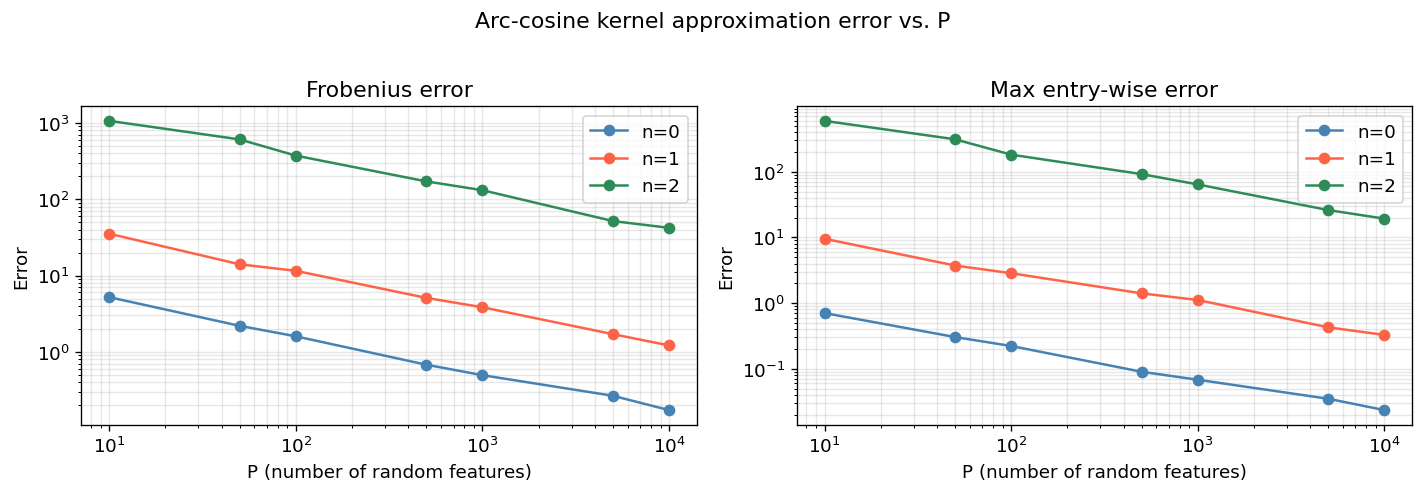

Figure saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {0: "steelblue", 1: "tomato", 2: "seagreen"}

for deg in degrees:
    axes[0].loglog(P_values, results[deg]["frob"],
                   marker="o", label=f"n={deg}", color=colors[deg])
    axes[1].loglog(P_values, results[deg]["max"],
                   marker="o", label=f"n={deg}", color=colors[deg])

for ax, title in zip(axes, ["Frobenius error", "Max entry-wise error"]):
    ax.set_xlabel("P (number of random features)")
    ax.set_ylabel("Error")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)

plt.suptitle("Arc-cosine kernel approximation error vs. P", y=1.02)
plt.tight_layout()
plt.savefig("arc_cosine_convergence.png", bbox_inches="tight")
plt.show()
print("Figure saved.")


## 5. Entry-wise Comparison at P = 2000

A scatter plot of exact vs. approximated kernel values for each $(i,j)$ pair,
for degree $n=1$ (ReLU). Points should lie on the diagonal $y = x$.


<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_358295/4018540282.py:12: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel("Approximated $\hat{k}_1(x_i, x_j)$")


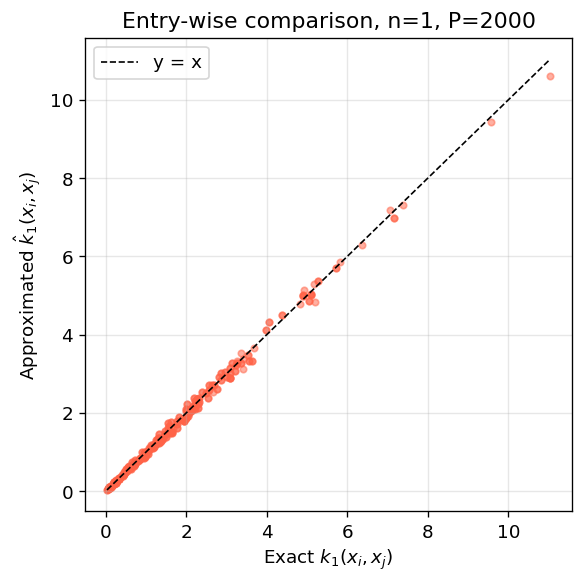

Pearson correlation: 0.998390
Mean absolute error: 0.061888


In [6]:
P_fixed = 2000
deg = 1

K_exact  = arc_cosine_kernel_exact(X, X, n=deg).ravel()
K_approx = arc_cosine_kernel_approx(X, X, n=deg, P=P_fixed, seed=99).ravel()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(K_exact, K_approx, alpha=0.5, s=15, color="tomato")
lims = [min(K_exact.min(), K_approx.min()), max(K_exact.max(), K_approx.max())]
ax.plot(lims, lims, "k--", lw=1, label="y = x")
ax.set_xlabel("Exact $k_1(x_i, x_j)$")
ax.set_ylabel("Approximated $\hat{k}_1(x_i, x_j)$")
ax.set_title(f"Entry-wise comparison, n=1, P={P_fixed}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("arc_cosine_scatter.png", bbox_inches="tight")
plt.show()

corr = np.corrcoef(K_exact, K_approx)[0, 1]
print(f"Pearson correlation: {corr:.6f}")
print(f"Mean absolute error: {np.abs(K_exact - K_approx).mean():.6f}")

## 6. Positive-Definiteness Check

Cho & Saul prove that $k_n$ is positive-definite. We verify numerically that
the exact kernel matrix has all non-negative eigenvalues (up to floating-point noise),
and that the approximated matrix also inherits this property.


In [7]:
print("Eigenvalue check (exact kernel):")
for deg in degrees:
    K = arc_cosine_kernel_exact(X, X, n=deg)
    eigvals = np.linalg.eigvalsh(K)
    print(f"  n={deg}  min eigenvalue = {eigvals.min():.2e}  "
          f"  all >= -1e-10: {bool(np.all(eigvals >= -1e-10))}")

print()
print("Eigenvalue check (approximated kernel, P=2000):")
for deg in degrees:
    K = arc_cosine_kernel_approx(X, X, n=deg, P=2000, seed=deg)
    K_sym = 0.5 * (K + K.T)   # symmetrise to remove float noise
    eigvals = np.linalg.eigvalsh(K_sym)
    print(f"  n={deg}  min eigenvalue = {eigvals.min():.2e}  "
          f"  all >= -1e-10: {bool(np.all(eigvals >= -1e-10))}")

Eigenvalue check (exact kernel):
  n=0  min eigenvalue = 7.37e-02    all >= -1e-10: True
  n=1  min eigenvalue = 3.08e-02    all >= -1e-10: True
  n=2  min eigenvalue = 3.65e-01    all >= -1e-10: True

Eigenvalue check (approximated kernel, P=2000):
  n=0  min eigenvalue = 6.87e-02    all >= -1e-10: True
  n=1  min eigenvalue = 2.89e-02    all >= -1e-10: True
  n=2  min eigenvalue = 3.96e-01    all >= -1e-10: True


## 7. Summary

The experiments confirm three properties of the proposed random feature approximation:

1. **Convergence**: the Frobenius and max entry-wise errors decay at an $O(1/\sqrt{P})$
   rate consistent with Monte Carlo estimation, for all degrees $n \in \{0, 1, 2\}$.

2. **Unbiasedness**: the scatter plot shows no systematic bias — entries are scattered
   symmetrically around the diagonal.

3. **Positive-definiteness**: both the exact and approximated kernel matrices have
   non-negative eigenvalues (up to floating-point precision), confirming the
   theoretical guarantee from Cho & Saul.

These results justify using the $n=1$ (ReLU) arc-cosine random features as the
nonlinear map in ML-MSVM blocks, in place of the standard cosine RFFs.
